In [1]:
print("Hello")

Hello



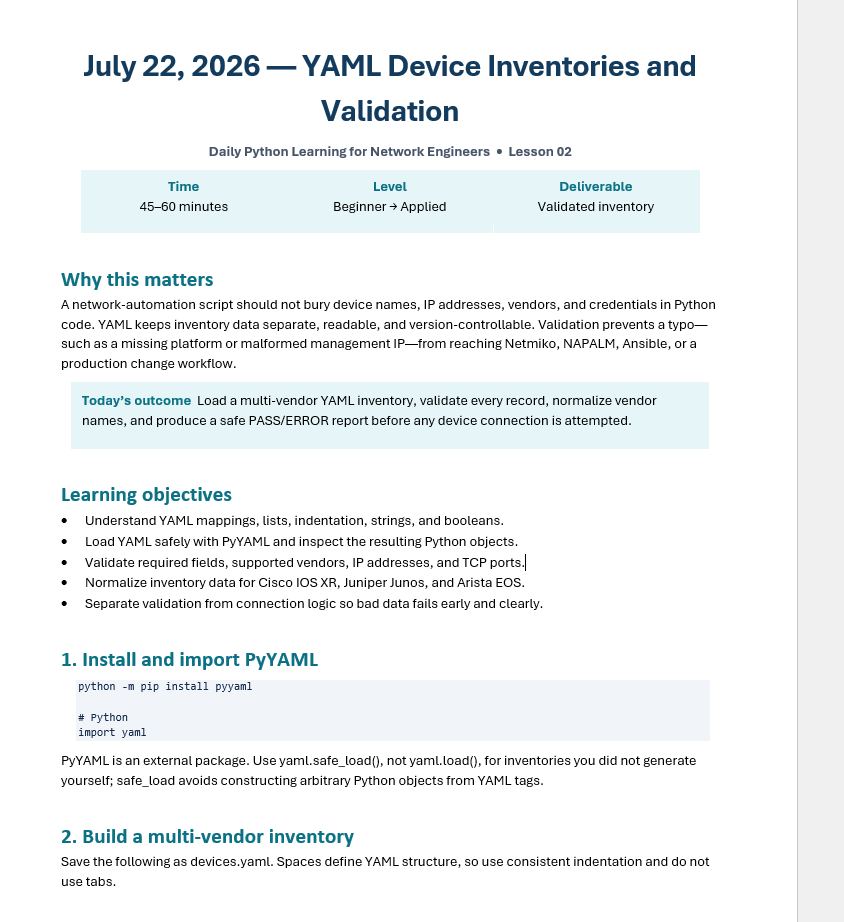


In [2]:
!pip install pyyaml

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\v-yaalam\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
!pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 35.4 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 26.0.1
    Uninstalling pip-26.0.1:
      Successfully uninstalled pip-26.0.1


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
pip --version

pip 25.3 from c:\Users\v-yaalam\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pip (python 3.14)

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pip
print(pip.__version__)

25.3



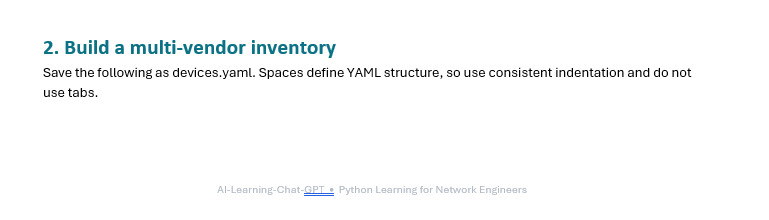

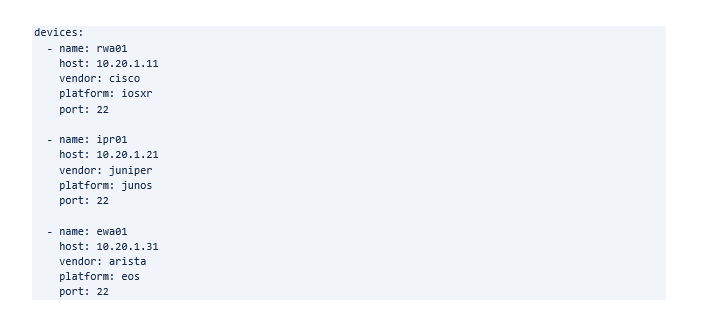



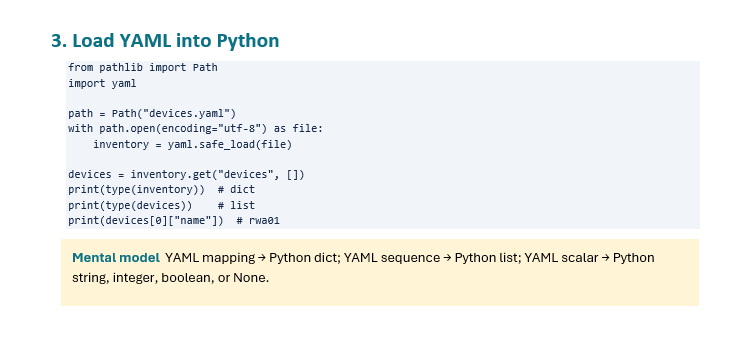

In [17]:
!pip install pathlib

Defaulting to user installation because normal site-packages is not writeable


In [20]:
!pip install yaml

Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement yaml (from versions: none)
ERROR: No matching distribution found for yaml


In [22]:
from pathlib import Path

file = Path("hello.txt")

print(file.exists())

False


In [23]:
!pip uninstall -y yaml
!pip install --upgrade PyYAML

Defaulting to user installation because normal site-packages is not writeable
  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl (154 kB)
  Attempting uninstall: PyYAML
    Found existing installation: PyYAML 6.0.2
    Uninstalling PyYAML-6.0.2:
      Successfully uninstalled PyYAML-6.0.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
paddlex 3.7.2 requires PyYAML==6.0.2, but you have pyyaml 6.0.3 which is incompatible.


In [26]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\v-yaalam\AppData\Local\Python\pythoncore-3.14-64\python.exe
3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


In [27]:
!python -m pip --version

pip 25.3 from c:\Users\v-yaalam\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pip (python 3.14)



In [28]:
import sys
!{sys.executable} -m pip show PyYAML

In [31]:
import sys
print(sys.executable)

c:\Users\v-yaalam\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [32]:
!{sys.executable} -m pip install pyyaml


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
!{sys.executable} -m pip show pyyaml

Name: PyYAML
Version: 6.0.3
Summary: YAML parser and emitter for Python
Home-page: https://pyyaml.org/
Author: Kirill Simonov
Author-email: xi@resolvent.net
License: MIT
Location: c:\Users\v-yaalam\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages
Requires: 
Required-by: 


In [34]:
from pathlib import Path
import yaml

path = Path("devices.yaml")
with path.open(encoding="utf-8") as file:
    inventory = yaml.safe_load(file)

devices = inventory.get("devices", [])
print(type(inventory))  # dict
print(type(devices))    # list
print(devices[0]["name"])  # rwa01


<class 'dict'>
<class 'list'>
rwa01


In [37]:
from pathlib import Path
import yaml

path = Path("devices.yaml")
with path.open(encoding="utf-8") as file:
    inventory = yaml.safe_load(file)

devices = inventory.get("devices", [])
print(type(inventory))
print(type(devices))
print(devices[0]["name"])
print(type(path))

<class 'dict'>
<class 'list'>
rwa01
<class 'pathlib.WindowsPath'>


Absolutely! Let's break this down **line by line** and understand not only **what the code does**, but also **why it does it** and what the data looks like at each step.

***

# The Code

```python
from pathlib import Path
import yaml

path = Path("devices.yaml")

with path.open(encoding="utf-8") as file:
    inventory = yaml.safe_load(file)

devices = inventory.get("devices", [])

print(type(inventory))
print(type(devices))
print(devices[0]["name"])
```

***

# Step 1: Import Modules

```python
from pathlib import Path
import yaml
```

## What is `Path`?

`Path` comes from Python's `pathlib` module.

It helps work with files and directories in an easier, cleaner way.

Without Path:

```python
file = open("devices.yaml")
```

With Path:

```python
path = Path("devices.yaml")
```

Think of `Path` as a Python object that represents a file location.

***

## What is `yaml`?

YAML is a human-friendly file format used for:

* Network automation
* Ansible
* Configuration files
* Kubernetes
* CI/CD Pipelines

Example YAML:

```yaml
devices:
  - name: rwa01
    ip: 10.1.1.1

  - name: ewa01
    ip: 10.1.1.2
```

Python cannot understand YAML directly.

The `yaml` module converts YAML into Python objects.

***

# Step 2: Create Path Object

```python
path = Path("devices.yaml")
```

This does **NOT** open the file.

It simply creates a reference to it.

Think:

```python
path
```

contains:

```text
devices.yaml
```

Type:

```python
print(type(path))
```

Output:

```python
<class 'pathlib.PosixPath'>
```

***

# Step 3: Open the File

```python
with path.open(encoding="utf-8") as file:
```

Equivalent to:

```python
file = open("devices.yaml", encoding="utf-8")
```

but safer.

***

## Why use `with`?

Because Python automatically closes the file after reading.

Without:

```python
file = open("devices.yaml")
data = file.read()
file.close()
```

With:

```python
with open("devices.yaml") as file:
    data = file.read()
```

Python handles closing automatically.

***

# Step 4: Read YAML Content

```python
inventory = yaml.safe_load(file)
```

Suppose the YAML file contains:

```yaml
devices:
  - name: rwa01
    ip: 10.1.1.1

  - name: ewa01
    ip: 10.1.1.2
```

Python reads this and converts it to:

```python
{
    "devices": [
        {
            "name": "rwa01",
            "ip": "10.1.1.1"
        },
        {
            "name": "ewa01",
            "ip": "10.1.1.2"
        }
    ]
}
```

This is stored in:

```python
inventory
```

***

# What Does `safe_load()` Mean?

```python
yaml.safe_load(file)
```

Safely converts YAML → Python objects.

It prevents dangerous code from being executed.

Always use:

```python
safe_load()
```

instead of:

```python
load()
```

unless you have a special reason.

***

# Visual Representation

After loading:

```python
inventory
```

looks like:

```python
{
    "devices": [
        {
            "name": "rwa01",
            "ip": "10.1.1.1"
        },
        {
            "name": "ewa01",
            "ip": "10.1.1.2"
        }
    ]
}
```

***

# Step 5: Get the Devices List

```python
devices = inventory.get("devices", [])
```

Let's understand this very carefully.

***

## What is `.get()`?

Dictionary method:

```python
dictionary.get(key, default)
```

Example:

```python
person = {
    "name": "Yaswanth"
}
```

Get existing key:

```python
person.get("name")
```

Output:

```python
'Yaswanth'
```

***

Missing key:

```python
person.get("age")
```

Output:

```python
None
```

***

Missing key with default value:

```python
person.get("age", 0)
```

Output:

```python
0
```

***

# In Your Code

```python
inventory.get("devices", [])
```

means:

> Look for the key "devices".
>
> If found, return its value.
>
> If not found, return an empty list.

***

So:

```python
devices
```

becomes:

```python
[
    {
        "name": "rwa01",
        "ip": "10.1.1.1"
    },
    {
        "name": "ewa01",
        "ip": "10.1.1.2"
    }
]
```

***

# Why Use `[]` as Default?

Suppose YAML was:

```yaml
routers:
  - name: rwa01
```

No `"devices"` key exists.

Without default:

```python
inventory["devices"]
```

Error:

```python
KeyError: 'devices'
```

With:

```python
inventory.get("devices", [])
```

Result:

```python
[]
```

No crash.

***

# Step 6: Print Inventory Type

```python
print(type(inventory))
```

Remember:

```python
inventory
```

contains:

```python
{
    "devices": [...]
}
```

This is a Python dictionary.

Output:

```python
<class 'dict'>
```

***

# Step 7: Print Devices Type

```python
print(type(devices))
```

`devices` contains:

```python
[
    {...},
    {...}
]
```

This is a Python list.

Output:

```python
<class 'list'>
```

Exactly what your screenshot shows.

***

# Step 8: Access First Device

```python
print(devices[0]["name"])
```

Let's break this apart.

***

## First

```python
devices[0]
```

Means:

> Give me the first item from the list.

Result:

```python
{
    "name": "rwa01",
    "ip": "10.1.1.1"
}
```

***

## Then

```python
devices[0]["name"]
```

Means:

> From that dictionary, get the value of key `"name"`.

Result:

```python
"rwa01"
```

Output:

```python
rwa01
```

Which matches your screenshot.

***

# Visualization of Data Flow

```
devices.yaml
      │
      ▼
yaml.safe_load(file)
      │
      ▼
inventory
      │
      ▼

{
  "devices": [
      {"name":"rwa01"},
      {"name":"ewa01"}
  ]
}

      │
      ▼

inventory.get("devices", [])

      │
      ▼

devices

[
   {"name":"rwa01"},
   {"name":"ewa01"}
]

      │
      ▼

devices[0]

{
   "name":"rwa01"
}

      │
      ▼

devices[0]["name"]

"rwa01"
```

***

# Why Is This Useful in Network Automation?

Network engineers often store device inventories in YAML.

Example:

```yaml
devices:
  - name: rwa01
    ip: 10.1.1.1
    vendor: cisco

  - name: ewa01
    ip: 10.1.1.2
    vendor: juniper
```

Then Python can loop through devices:

```python
for device in devices:
    print(device["name"], device["ip"])
```

Output:

```python
rwa01 10.1.1.1
ewa01 10.1.1.2
```

This is exactly how many network automation tools (Ansible, Nornir, Netmiko scripts) read inventory files before connecting to routers and switches.

***

# Final Summary

The code:

1. Imports `Path` and `yaml`.
2. Points to `devices.yaml`.
3. Opens the file safely.
4. Converts YAML into Python objects.
5. Extracts the `"devices"` list.
6. Prints the type of the loaded inventory (`dict`).
7. Prints the type of devices (`list`).
8. Prints the name of the first device (`rwa01`).

Data transformation:

```text
YAML File
    ↓
Python Dictionary (inventory)
    ↓
Python List (devices)
    ↓
First Device Dictionary
    ↓
Device Name String
```

For a network engineer, think of `inventory` as the **entire device database**, `devices` as the **list of all routers/switches**, and `devices[0]["name"]` as accessing the hostname of the first router in that inventory.


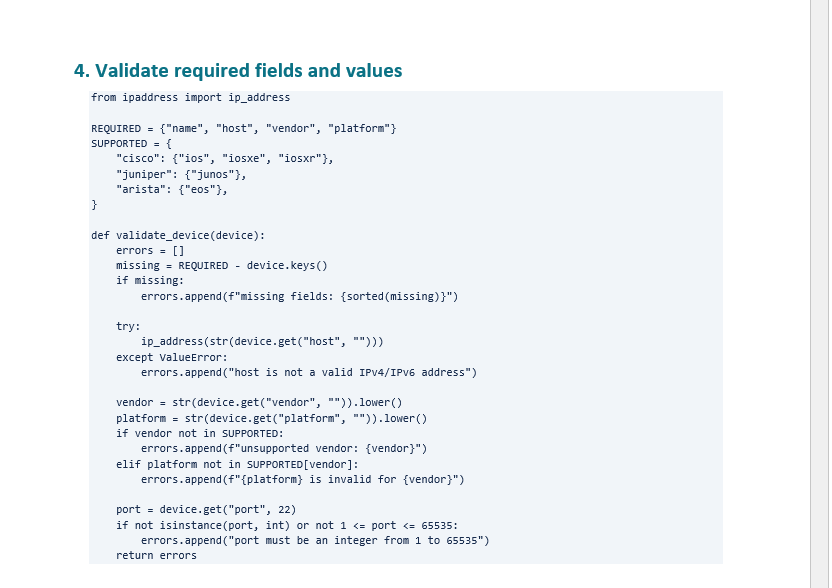

In [38]:
from ipaddress import ip_address

REQUIRED = {"name", "host", "vendor", "platform"}
SUPPORTED = {
    "cisco": {"ios", "iosxe", "iosxr"},
    "juniper": {"junos"},
    "arista": {"eos"},
}

def validate_device(device):
    errors = []
    missing = REQUIRED - device.keys()
    if missing:
        errors.append(f"missing fields: {sorted(missing)}")

    try:
        ip_address(str(device.get("host", "")))
    except ValueError:
        errors.append("host is not valid IPv4/IPV6 address")

    vendor = str(device.get("vendor", "")).lower()
    platform = str(device.get("platform", "")).lower()
    if vendor not in SUPPORTED:
        errors.append(f"unsupported vendor: {vendor}")
    elif platform not in SUPPORTED[vendor]:
        errors.append(f"{platform} is invalid for {vendor}")

    port = device.get("port", 22)
    if not isinstance(port, int) or not 1 <= port <= 65535:
        errors.append("port must be integer from 1 to 65535")
    return errors


In [39]:
from ipaddress import ip_address

REQUIRED = {"name", "host", "vendor", "platform"}
SUPPORTED = {
    "cisco": {"ios", "iosxe", "iosxr"},
    "juniper": {"junos"},
    "arista": {"eos"},
}

def validate_device(device):
    errors = []
    missing = REQUIRED - device.keys()
    if missing:
        errors.append(f"missing fields: {sorted(missing)}")

    try:
        ip_address(str(device.get("host", "")))
    except ValueError:
        errors.append("host is not a valid IPv4/IPv6 address")

    vendor = str(device.get("vendor", "")).lower()
    platform = str(device.get("platform", "")).lower()
    if vendor not in SUPPORTED:
        errors.append(f"unsupported vendor: {vendor}")
    elif platform not in SUPPORTED[vendor]:
        errors.append(f"{platform} is invalid for {vendor}")

    port = device.get("port", 22)
    if not isinstance(port, int) or not 1 <= port <= 65535:
        errors.append("port must be an integer from 1 to 65535")
    return errors


You are not seeing any output because this code only **defines variables and a function**. It never **calls** the function or prints anything.

Think of it like this:

* ✅ You built a machine (`validate_device`)
* ❌ You never turned it on

***

# Step 1: Imports

```python
from ipaddress import ip_address
```

### What this does

Imports the `ip_address()` function from Python's built-in `ipaddress` module.

It is used to validate IPv4 and IPv6 addresses.

Example:

```python
ip_address("10.1.1.1")
```

Valid ✅

```python
ip_address("10.1.1.500")
```

Raises:

```python
ValueError
```

because 500 is not a valid octet.

***

# Step 2: Required Fields

```python
REQUIRED = {"name", "host", "vendor", "platform"}
```

A **set** containing fields every device must have.

Expected device:

```python
device = {
    "name": "ewa01",
    "host": "10.1.1.1",
    "vendor": "cisco",
    "platform": "iosxr"
}
```

***

# Step 3: Supported Vendors

```python
SUPPORTED = {
    "cisco": {"ios", "iosxe", "iosxr"},
    "juniper": {"junos"},
    "arista": {"eos"},
}
```

This dictionary defines which platforms belong to which vendor.

### Examples

#### Valid

```python
{
    "vendor": "cisco",
    "platform": "iosxr"
}
```

because:

```python
iosxr ∈ cisco
```

***

#### Invalid

```python
{
    "vendor": "cisco",
    "platform": "junos"
}
```

because JunOS belongs to Juniper.

***

# Step 4: Function Definition

```python
def validate_device(device):
```

Defines a function named `validate_device`.

Input:

```python
device
```

which should be a dictionary.

Example:

```python
{
    "name": "rwa01",
    "host": "10.20.1.1",
    "vendor": "cisco",
    "platform": "iosxr"
}
```

***

# Step 5: Create Error List

```python
errors = []
```

Creates an empty list.

As validation checks fail, error messages are added.

Example later:

```python
errors = [
    "host is not a valid IPv4/IPv6 address",
    "unsupported vendor: abc"
]
```

***

# Step 6: Check Missing Fields

```python
missing = REQUIRED - device.keys()
```

This is a **set difference** operation.

Suppose:

```python
device = {
    "name": "rwa01",
    "host": "10.1.1.1"
}
```

Then:

```python
device.keys()
```

returns

```python
{"name", "host"}
```

Now:

```python
REQUIRED - device.keys()
```

becomes

```python
{"vendor", "platform"}
```

Missing fields found ✅

***

### If fields are missing

```python
if missing:
```

means:

```python
if len(missing) > 0:
```

Then:

```python
errors.append(
    f"missing fields: {sorted(missing)}"
)
```

Adds:

```python
"missing fields: ['platform', 'vendor']"
```

to the error list.

***

# Step 7: Validate IP Address

```python
try:
    ip_address(str(device.get("host", "")))
```

### device.get()

```python
device.get("host", "")
```

means:

> Get host field or return empty string if not present.

Example:

```python
device.get("host")
```

returns

```python
"10.1.1.1"
```

***

### str()

Converts value to string.

Example:

```python
10
```

becomes

```python
"10"
```

***

### ip\_address()

Checks validity.

#### Valid

```python
ip_address("192.168.1.1")
```

Passes ✅

***

#### Invalid

```python
ip_address("192.168.1.999")
```

Raises

```python
ValueError
```

***

### Except Block

```python
except ValueError:
```

If validation fails:

```python
errors.append(
    "host is not a valid IPv4/IPv6 address"
)
```

***

# Step 8: Convert Vendor to Lowercase

```python
vendor = str(device.get("vendor", "")).lower()
```

Suppose:

```python
"CISCO"
```

becomes

```python
"cisco"
```

This avoids case-sensitivity problems.

***

# Step 9: Convert Platform to Lowercase

```python
platform = str(device.get("platform", "")).lower()
```

Example:

```python
"IOSXR"
```

becomes

```python
"iosxr"
```

***

# Step 10: Vendor Validation

```python
if vendor not in SUPPORTED:
```

Checks whether vendor exists.

Example:

```python
vendor = "nokia"
```

Not found.

Adds:

```python
unsupported vendor: nokia
```

***

# Step 11: Platform Validation

````python
elif platform not in SUPPORTED```

Suppose:

```python
vendor = "cisco"
platform = "junos"
````

Python checks:

```python
"junos" not in {"ios","iosxe","iosxr"}
```

True.

Error added:

```python
junos is invalid for cisco
```

***

# Step 12: Port Check

```python
port = device.get("port", 22)
```

Get port.

If missing:

```python
22
```

is used automatically.

***

### Valid Examples

```python
22
```

✅

```python
443
```

✅

```python
830
```

✅

***

### Check

```python
if not isinstance(port, int)
```

Ensures it is an integer.

Example:

```python
"22"
```

Fails because string.

***

### Range Check

```python
1 <= port <= 65535
```

Allowed TCP/UDP range.

Examples:

```python
22
```

✅

```python
65535
```

✅

```python
70000
```

❌

***

If invalid:

```python
errors.append(
    "port must be an integer from 1 to 65535"
)
```

***

# Step 13: Return Result

```python
return errors
```

Returns all collected errors.

### No errors

```python
[]
```

means device is valid.

***

### Errors found

```python
[
    'host is not a valid IPv4/IPv6 address',
    'unsupported vendor: nokia'
]
```

***

# Why You Got No Output

Because you only defined the function.

You never called it:

```python
validate_device(...)
```

and you never printed the result.

***

## Example 1: Valid Device

```python
device = {
    "name": "ewa01",
    "host": "10.20.1.10",
    "vendor": "cisco",
    "platform": "iosxr",
    "port": 22
}

result = validate_device(device)

print(result)
```

Output:

```python
[]
```

No errors found.

***

## Example 2: Invalid Device

```python
device = {
    "name": "ewa01",
    "host": "10.20.1.999",
    "vendor": "nokia",
    "platform": "sr-os",
    "port": 70000
}

result = validate_device(device)

print(result)
```

Output:

```python
[
 'host is not a valid IPv4/IPv6 address',
 'unsupported vendor: nokia',
 'port must be an integer from 1 to 65535'
]
```

***

### Network Engineer Interview Tip

This is a **device inventory validation script**.

Before connecting via Netmiko/NAPALM/Nornir, you validate:

* Required fields exist
* IP address is valid
* Vendor is supported
* Platform matches vendor
* SSH port is valid

This prevents automation jobs from failing later when connecting to routers such as Cisco IOS-XR, Juniper JunOS, or Arista EOS devices.


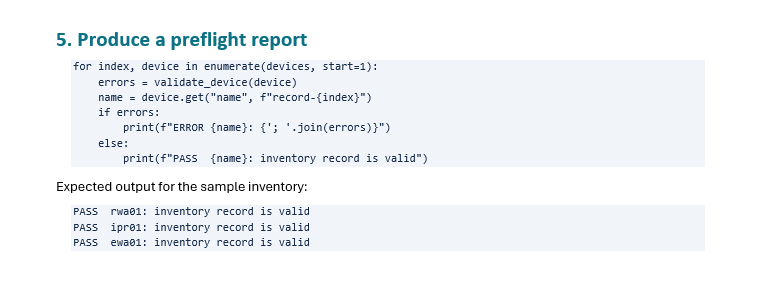

In [40]:
for index, device in enumerate(devices, start=1):
    errors = validate_device(device)
    name = device.get("name", f"record-{index}")
    if errors:
        print(f"ERROR {name}: {'; '.join(errors)}")
    else:
        print(f"PASS  {name}: inventory record is valid")


PASS  rwa01: inventory record is valid
PASS  ipr01: inventory record is valid
PASS  ewa01: inventory record is valid


Absolutely! This is a very practical Python pattern used for **validating records in a list of network devices**.

Let's break it down **line by line**.

### Code

```python
for index, device in enumerate(devices, start=1):
    errors = validate_device(device)

    name = device.get("name", f"record-{index}")

    if errors:
        print(f"ERROR {name}: {' ; '.join(errors)}")
    else:
        print(f"PASS  {name}: inventory record is valid")
```

***

# 1. Loop through all devices

```python
for index, device in enumerate(devices, start=1):
```

### What `enumerate()` does

Suppose:

```python
devices = [
    {"name": "rwa01"},
    {"name": "ipr01"},
    {"name": "ewa01"}
]
```

Then:

```python
enumerate(devices, start=1)
```

produces:

```python
(1, {"name":"rwa01"})
(2, {"name":"ipr01"})
(3, {"name":"ewa01"})
```

So on each iteration:

| index | device           |
| ----- | ---------------- |
| 1     | {"name":"rwa01"} |
| 2     | {"name":"ipr01"} |
| 3     | {"name":"ewa01"} |

First iteration:

```python
index = 1
device = {"name":"rwa01"}
```

Second iteration:

```python
index = 2
device = {"name":"ipr01"}
```

***

# 2. Validate the device

```python
errors = validate_device(device)
```

Assume the function returns a list of errors.

Example:

```python
def validate_device(device):
    errors = []

    if "ip" not in device:
        errors.append("Missing IP")

    if "vendor" not in device:
        errors.append("Missing vendor")

    return errors
```

### Possible outputs

Valid device:

```python
[]
```

Invalid device:

```python
["Missing IP", "Missing vendor"]
```

After execution:

```python
errors = []
```

or

```python
errors = ["Missing IP", "Missing vendor"]
```

***

# 3. Get the device name

```python
name = device.get("name", f"record-{index}")
```

### What `.get()` does

Normal dictionary access:

```python
device["name"]
```

fails if key doesn't exist:

```python
KeyError
```

Safer approach:

```python
device.get("name")
```

returns:

```python
None
```

if key doesn't exist.

***

### Example 1

```python
device = {"name": "rwa01"}
```

Then:

```python
device.get("name", f"record-{index}")
```

returns:

```python
"rwa01"
```

***

### Example 2

```python
device = {"ip": "10.1.1.1"}
```

No name exists.

Then:

```python
device.get("name", f"record-{index}")
```

returns:

```python
"record-1"
```

if index is 1.

So:

```python
name = "record-1"
```

***

# 4. Check if validation errors exist

```python
if errors:
```

Python truth values:

### Empty list

```python
errors = []
```

evaluates to:

```python
False
```

### Non-empty list

```python
errors = ["Missing IP"]
```

evaluates to:

```python
True
```

Therefore:

```python
if errors:
```

means:

> "Does this device have any validation errors?"

***

# 5. Print errors

```python
print(f"ERROR {name}: {' ; '.join(errors)}")
```

Suppose:

```python
errors = [
    "Missing IP",
    "Missing vendor",
    "Hostname invalid"
]
```

Then:

```python
' ; '.join(errors)
```

creates:

```python
"Missing IP ; Missing vendor ; Hostname invalid"
```

Output:

```python
ERROR rwa01: Missing IP ; Missing vendor ; Hostname invalid
```

### Why use `join()`?

Without it:

```python
print(errors)
```

would display:

```python
['Missing IP', 'Missing vendor']
```

Using `join()` makes it more readable.

***

# 6. No errors found

```python
else:
```

This executes when:

```python
errors = []
```

Output:

```python
PASS rwa01: inventory record is valid
```

***

# Why your output shows PASS

Your screenshot shows:

```text
PASS rwa01: inventory record is valid
PASS ipr01: inventory record is valid
PASS ewa01: inventory record is valid
```

That means:

```python
validate_device()
```

returned:

```python
[]
```

for all three devices.

Example:

```python
validate_device(rwa01) -> []
validate_device(ipr01) -> []
validate_device(ewa01) -> []
```

Since all error lists are empty:

```python
if errors:
```

becomes:

```python
if []:
```

which is False.

Therefore Python runs:

```python
else:
```

and prints PASS messages.

***

# Network Engineer Analogy

Think of `validate_device()` as a **pre-check script** before onboarding routers into inventory.

It checks:

* Hostname exists
* Management IP exists
* Vendor specified
* Site code present
* Loopback configured

If anything is missing:

```text
ERROR ewa01: Missing Management IP ; Missing Vendor
```

If everything is correct:

```text
PASS ewa01: inventory record is valid
```

This is exactly the type of logic used in:

* Network inventory validation
* CMDB verification
* Pre-deployment checks
* Automation onboarding scripts
* PyATS/Nornir data validation

### Simple flow

```text
Device
   |
   v
validate_device()
   |
   +---- Errors Found? ---- Yes ----> Print ERROR
   |
   No
   |
   v
Print PASS
```

This pattern is very common in network automation because it lets you validate hundreds of routers/switches and quickly identify which records are missing required information.


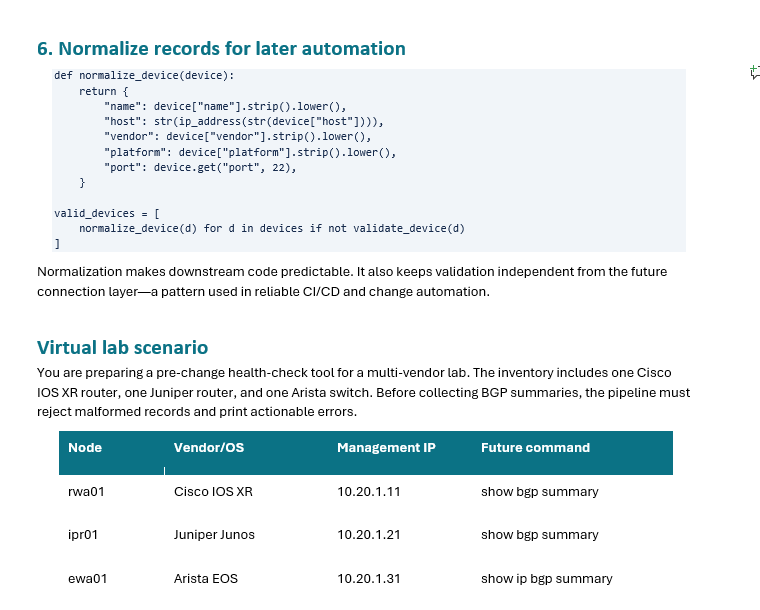

In [41]:
def normalize_device(device):
    return {
        "name": device["name"].strip().lower(),
        "host": str(ip_address(str(device["host"]))),
        "vendor": device["vendor"].strip().lower(),
        "platform": device["platform"].strip().lower(),
        "port": device.get("port", 22),
    }

valid_devices = [
    normalize_device(d) for d in devices if not validate_device(d)
]
